## Instrução do Projeto

A Film Junky Union, uma nova comunidade para entusiastas de filmes clássicos, está desenvolvendo um sistema para filtrar e categorizar resenhas de filmes. O objetivo é treinar um modelo para detectar automaticamente resenhas negativas. Você usará um conjunto de dados de resenhas de filmes do IMDB com rotulagem de polaridade para criar um modelo para classificar resenhas como positivas e negativas. Ele precisará ter um valor F1 de pelo menos 0,85.

## Inicialização

In [ ]:
import math

import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from tqdm.auto import tqdm


In [ ]:
%matplotlib inline
%config InlineBackend.figure_format = 'png'
# a próxima linha fornece gráficos de melhor qualidade em telas HiDPI
%config InlineBackend.figure_format = 'retina'

plt.style.use('seaborn')


In [ ]:
# isso é para usar progress_apply, leia mais em https://pypi.org/project/tqdm/#pandas-integration
tqdm.pandas()


## Carregar Dados

In [ ]:
df_reviews = pd.read_csv('/datasets/imdb_reviews.tsv', sep='\t', dtype={'votes': 'Int64'})


In [ ]:
df_reviews.head()


,tconst,title_type,primary_title,original_title,start_year,end_year,runtime_minutes,is_adult,genres,average_rating,votes,review,rating,sp,pos,ds_part,idx
0,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218,The pakage implies that Warren Beatty and Gold...,1,neg,0,train,8335
1,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218,How the hell did they get this made?! Presenti...,1,neg,0,train,8336
2,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,There is no real story the film seems more lik...,3,neg,0,test,2489
3,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,Um .... a serious film about troubled teens in...,7,pos,1,test,9280
4,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,I'm totally agree with GarryJohal from Singapo...,9,pos,1,test,9281


In [ ]:
df_reviews.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47331 entries, 0 to 47330
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tconst           47331 non-null  object 
 1   title_type       47331 non-null  object 
 2   primary_title    47331 non-null  object 
 3   original_title   47331 non-null  object 
 4   start_year       47331 non-null  int64  
 5   end_year         47331 non-null  object 
 6   runtime_minutes  47331 non-null  object 
 7   is_adult         47331 non-null  int64  
 8   genres           47331 non-null  object 
 9   average_rating   47329 non-null  float64
 10  votes            47329 non-null  Int64  
 11  review           47331 non-null  object 
 12  rating           47331 non-null  int64  
 13  sp               47331 non-null  object 
 14  pos              47331 non-null  int64  
 15  ds_part          47331 non-null  object 
 16  idx              47331 non-null  int64  
dtypes: Int64(1),

In [ ]:
df_reviews['ds_part'].value_counts()
df_reviews['pos'].value_counts()


0    23715
1    23616
Name: pos, dtype: int64

## AED

Vamos verificar o número de filmes e resenhas ao longo dos anos.

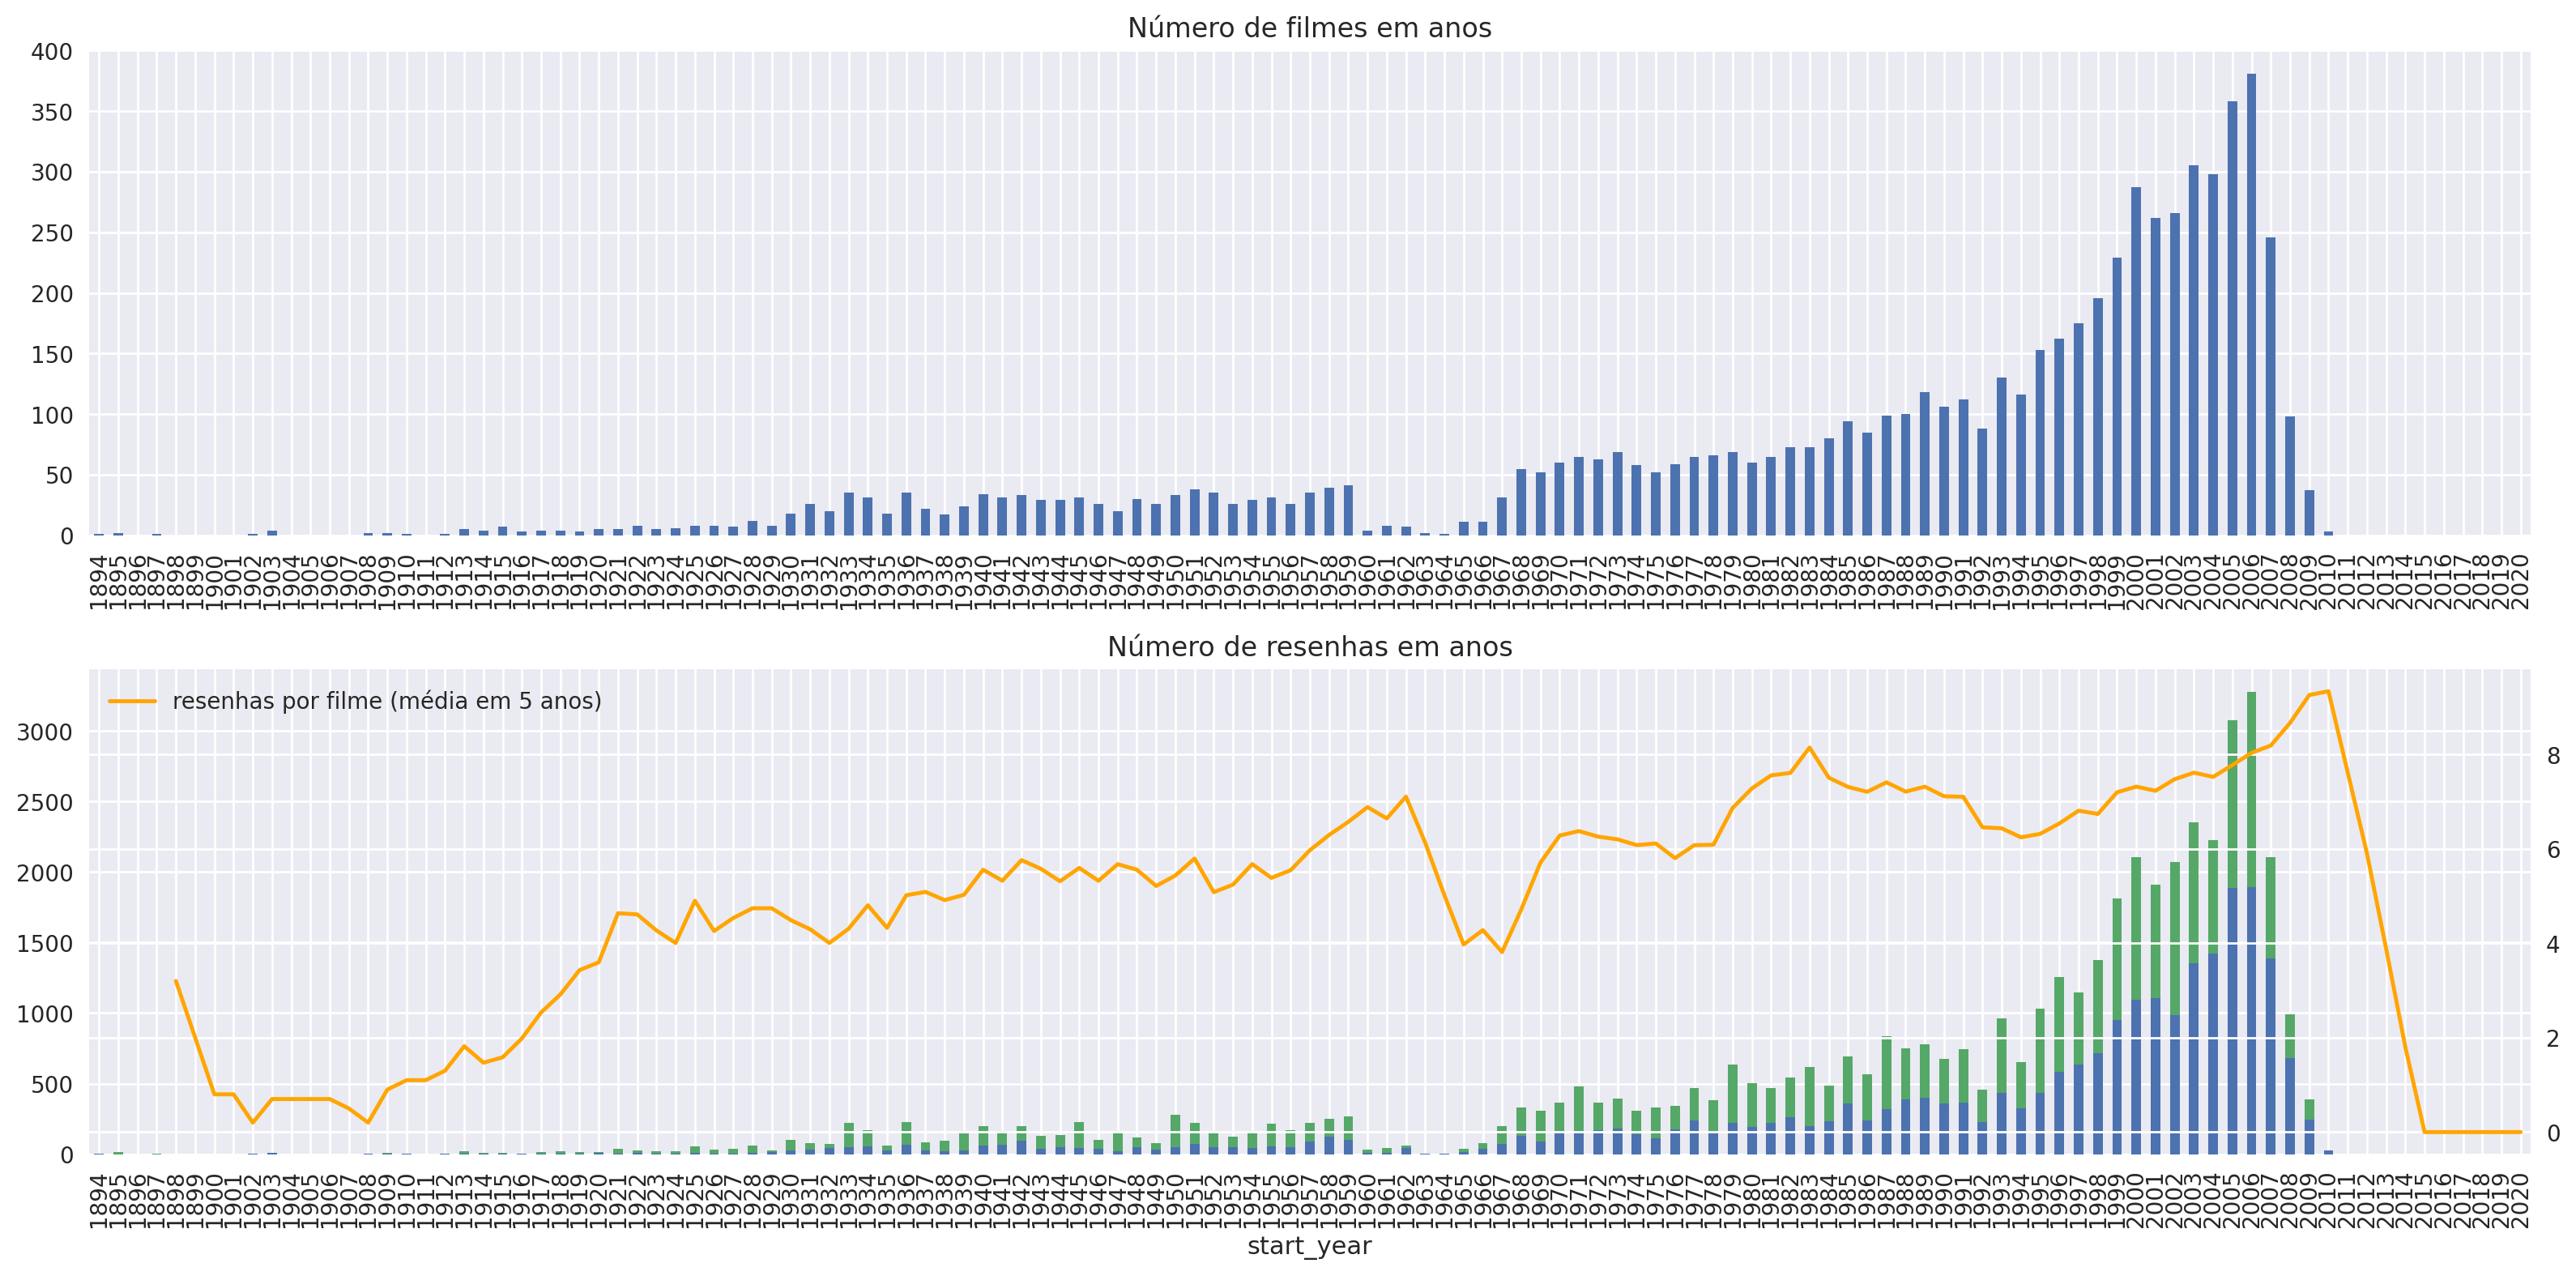

In [ ]:
fig, axs = plt.subplots(2, 1, figsize=(16, 8))

ax = axs[0]

dft1 = df_reviews[['tconst', 'start_year']].drop_duplicates() \
    ['start_year'].value_counts().sort_index()
dft1 = dft1.reindex(index=np.arange(dft1.index.min(), max(dft1.index.max(), 2021))).fillna(0)
dft1.plot(kind='bar', ax=ax)
ax.set_title('Número de filmes em anos')

ax = axs[1]

dft2 = df_reviews.groupby(['start_year', 'pos'])['pos'].count().unstack()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)

dft2.plot(kind='bar', stacked=True, label='#reviews (neg, pos)', ax=ax)

dft2 = df_reviews['start_year'].value_counts().sort_index()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)
dft3 = (dft2/dft1).fillna(0)
axt = ax.twinx()
dft3.reset_index(drop=True).rolling(5).mean().plot(color='orange', label='resenhas por filme (média em 5 anos)', ax=axt)

lines, labels = axt.get_legend_handles_labels()
ax.legend(lines, labels, loc='upper left')

ax.set_title('Número de resenhas em anos')

fig.tight_layout()


Vamos verificar a distribuição do número de resenhas por filme com a contagem exata e o EDK (Estimativa de densidade kernel - só para saber como pode diferir da contagem exata)

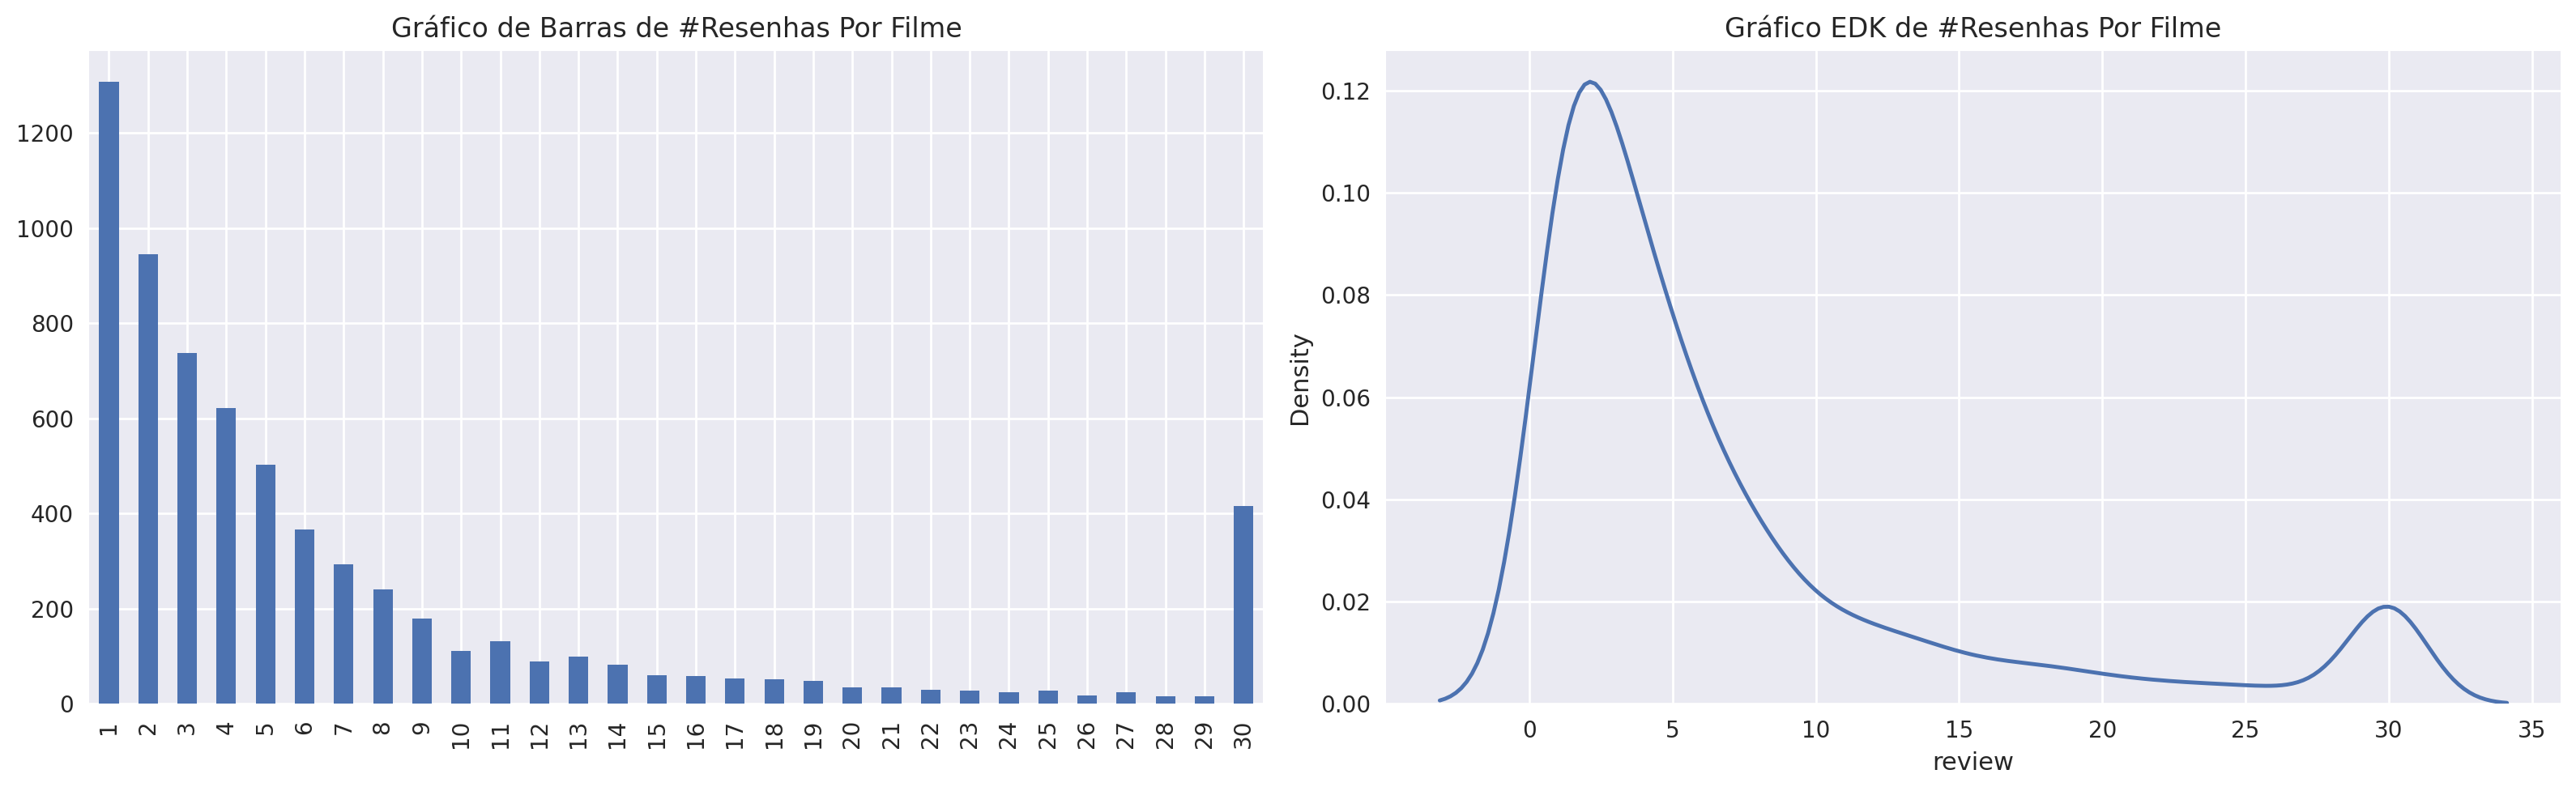

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(16, 5))

ax = axs[0]
dft = df_reviews.groupby('tconst')['review'].count() \
    .value_counts() \
    .sort_index()
dft.plot.bar(ax=ax)
ax.set_title('Gráfico de Barras de #Resenhas Por Filme')

ax = axs[1]
dft = df_reviews.groupby('tconst')['review'].count()
sns.kdeplot(dft, ax=ax)
ax.set_title('Gráfico EDK de #Resenhas Por Filme')

fig.tight_layout()


In [ ]:
df_reviews['pos'].value_counts()


0    23715
1    23616
Name: pos, dtype: int64

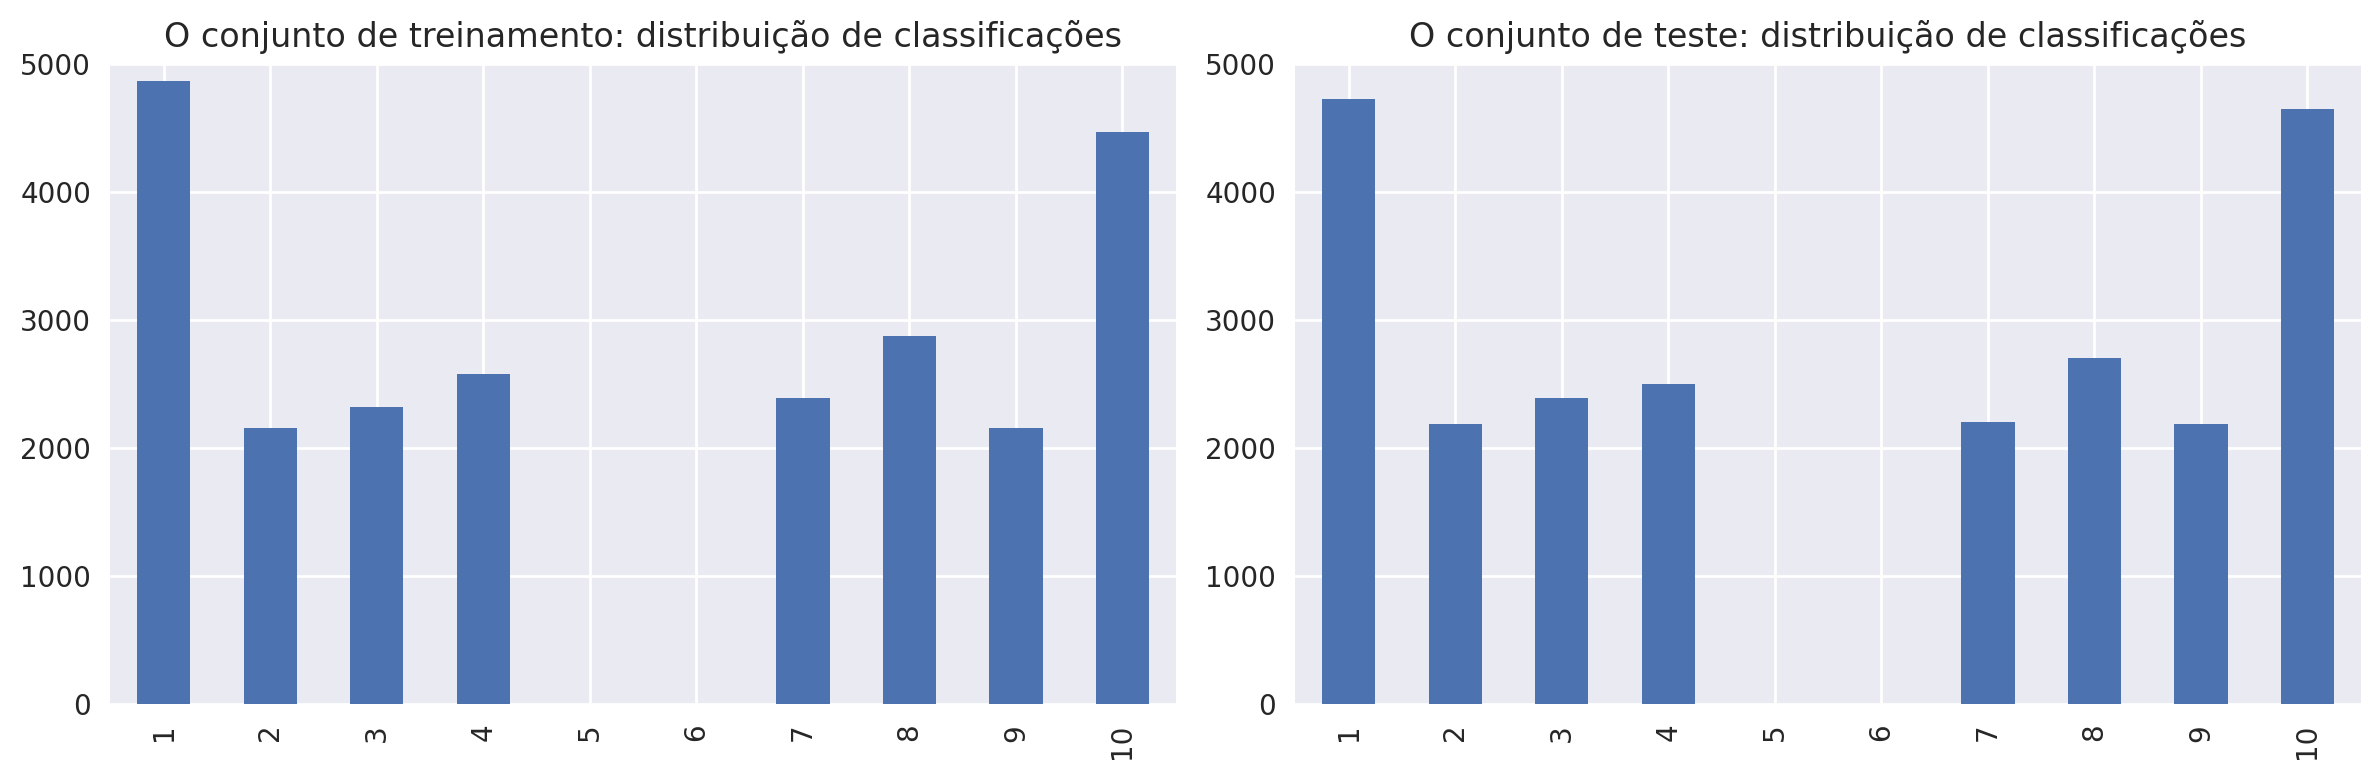

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

ax = axs[0]
dft = df_reviews.query('ds_part == "train"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('O conjunto de treinamento: distribuição de classificações')

ax = axs[1]
dft = df_reviews.query('ds_part == "test"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('O conjunto de teste: distribuição de classificações')

fig.tight_layout()


Distribuição de resenhas negativas e positivas ao longo dos anos para duas partes do conjunto de dados

/.venv/lib/python3.9/site-packages/seaborn/distributions.py:1666: UserWarning: Support for alternate kernels has been removed. Using Gaussian kernel.
  warnings.warn(msg, UserWarning)
/.venv/lib/python3.9/site-packages/seaborn/distributions.py:1666: UserWarning: Support for alternate kernels has been removed. Using Gaussian kernel.
  warnings.warn(msg, UserWarning)
/.venv/lib/python3.9/site-packages/seaborn/distributions.py:1666: UserWarning: Support for alternate kernels has been removed. Using Gaussian kernel.
  warnings.warn(msg, UserWarning)
/.venv/lib/python3.9/site-packages/seaborn/distributions.py:1666: UserWarning: Support for alternate kernels has been removed. Using Gaussian kernel.
  warnings.warn(msg, UserWarning)


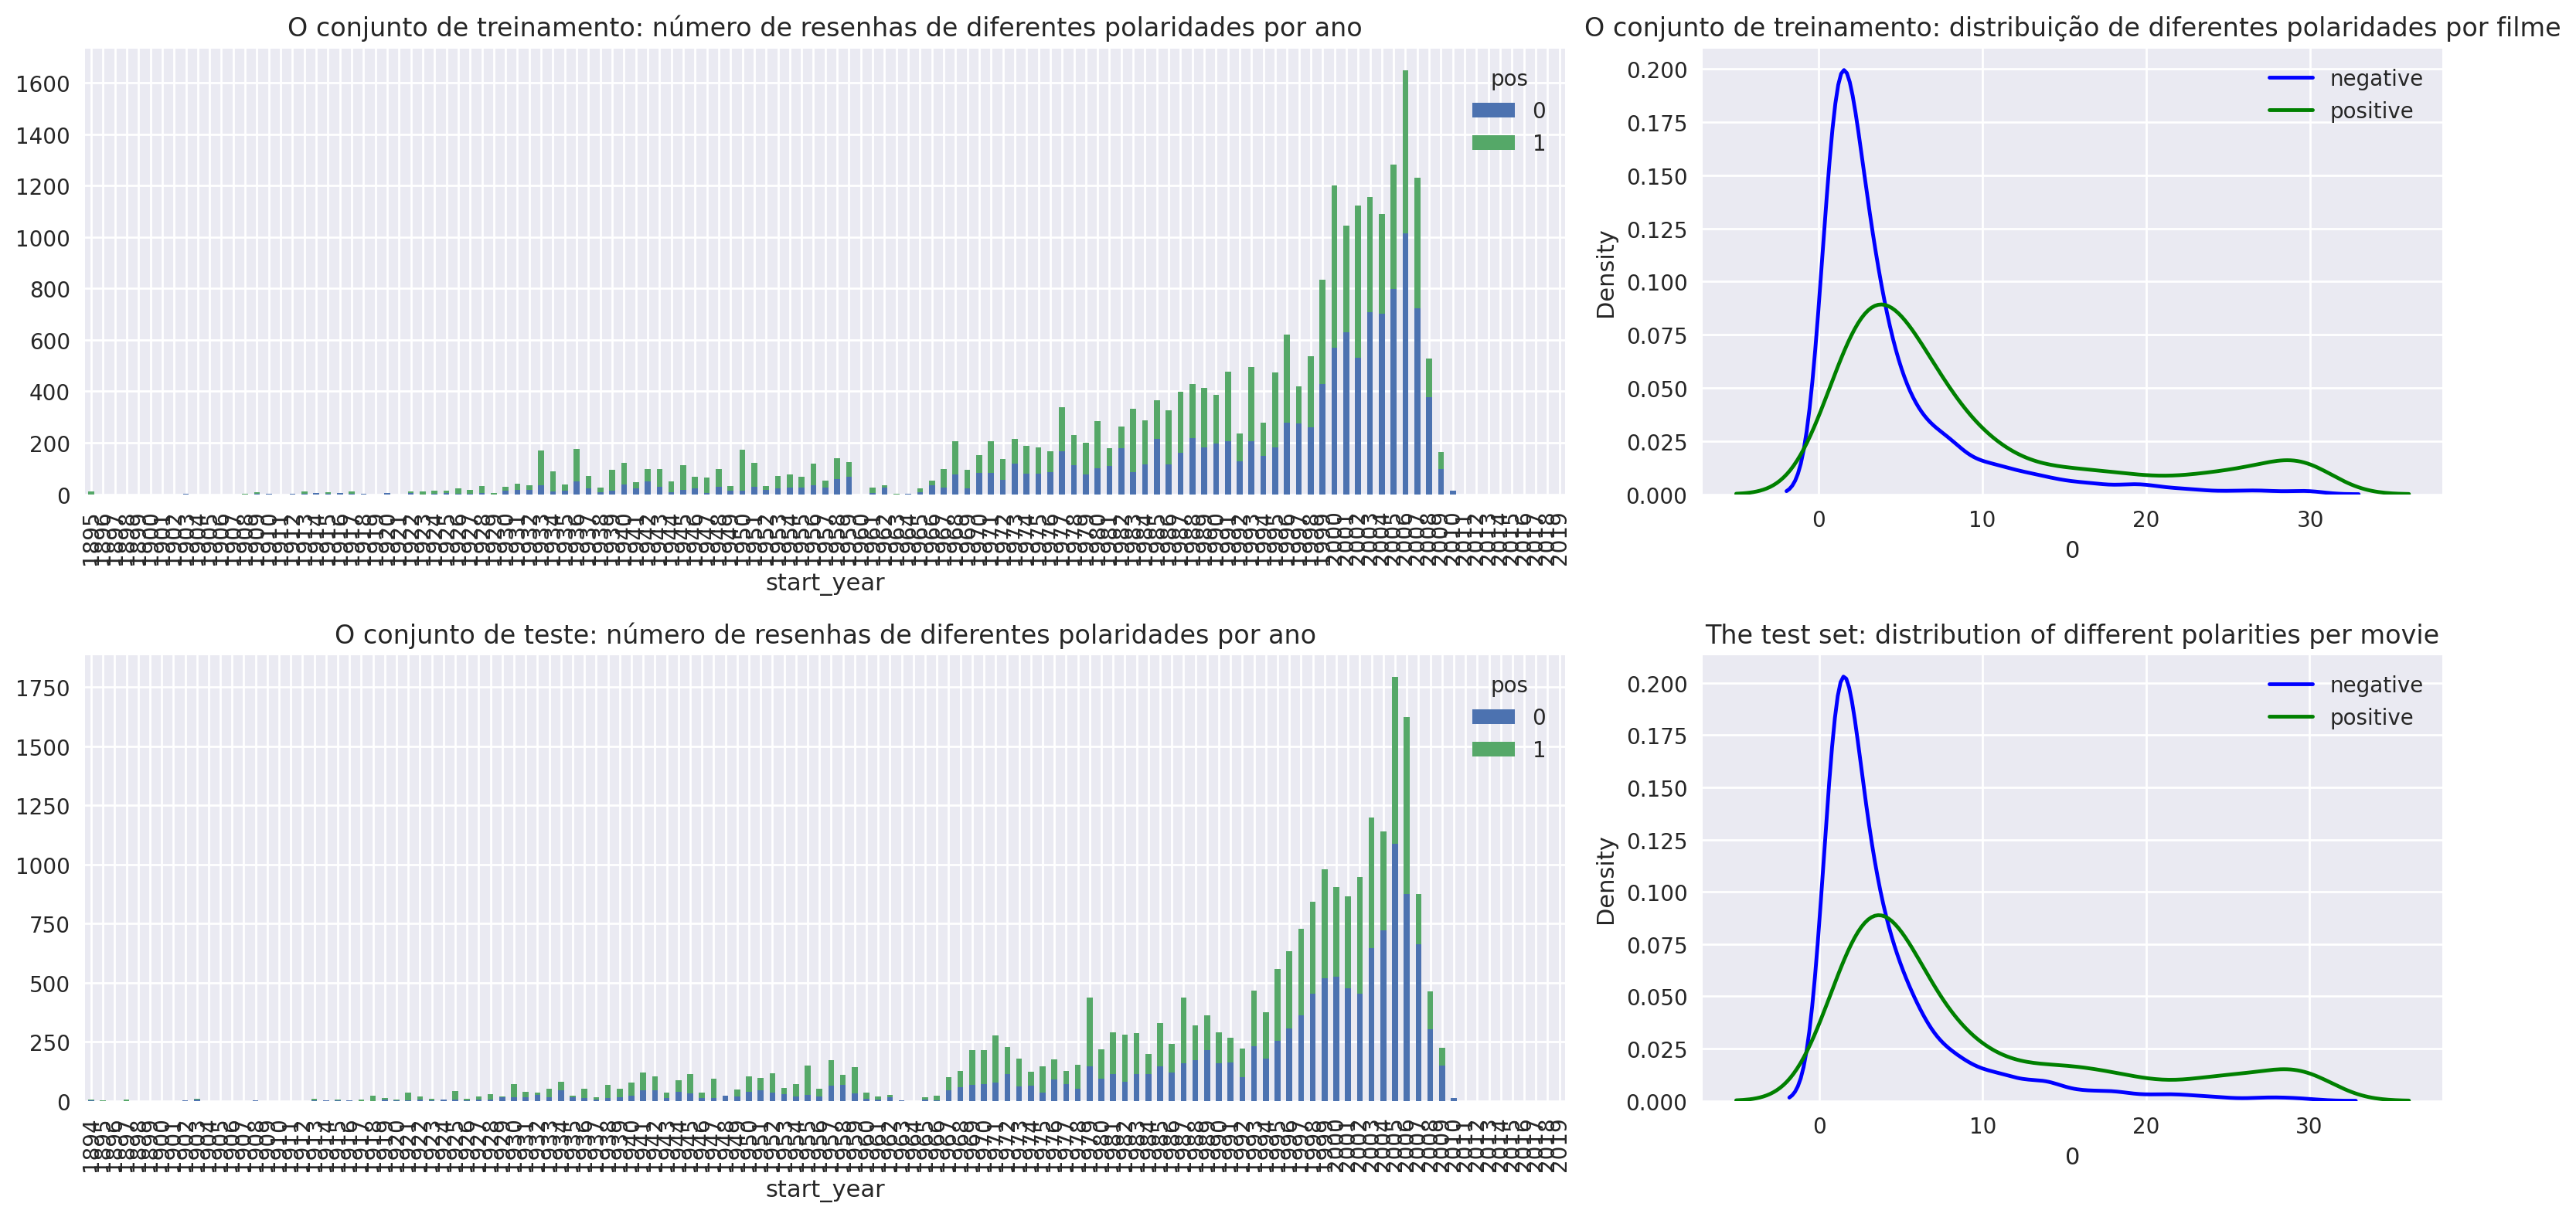

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(16, 8), gridspec_kw=dict(width_ratios=(2, 1), height_ratios=(1, 1)))

ax = axs[0][0]

dft = df_reviews.query('ds_part == "train"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('O conjunto de treinamento: número de resenhas de diferentes polaridades por ano')

ax = axs[0][1]

dft = df_reviews.query('ds_part == "train"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
ax.legend()
ax.set_title('O conjunto de treinamento: distribuição de diferentes polaridades por filme')

ax = axs[1][0]

dft = df_reviews.query('ds_part == "test"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('O conjunto de teste: número de resenhas de diferentes polaridades por ano')

ax = axs[1][1]

dft = df_reviews.query('ds_part == "test"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
ax.legend()
ax.set_title('The test set: distribution of different polarities per movie')

fig.tight_layout()


0    23715
1    23616
Name: pos, dtype: int64

0    50.104583
1    49.895417
Name: pos, dtype: float64

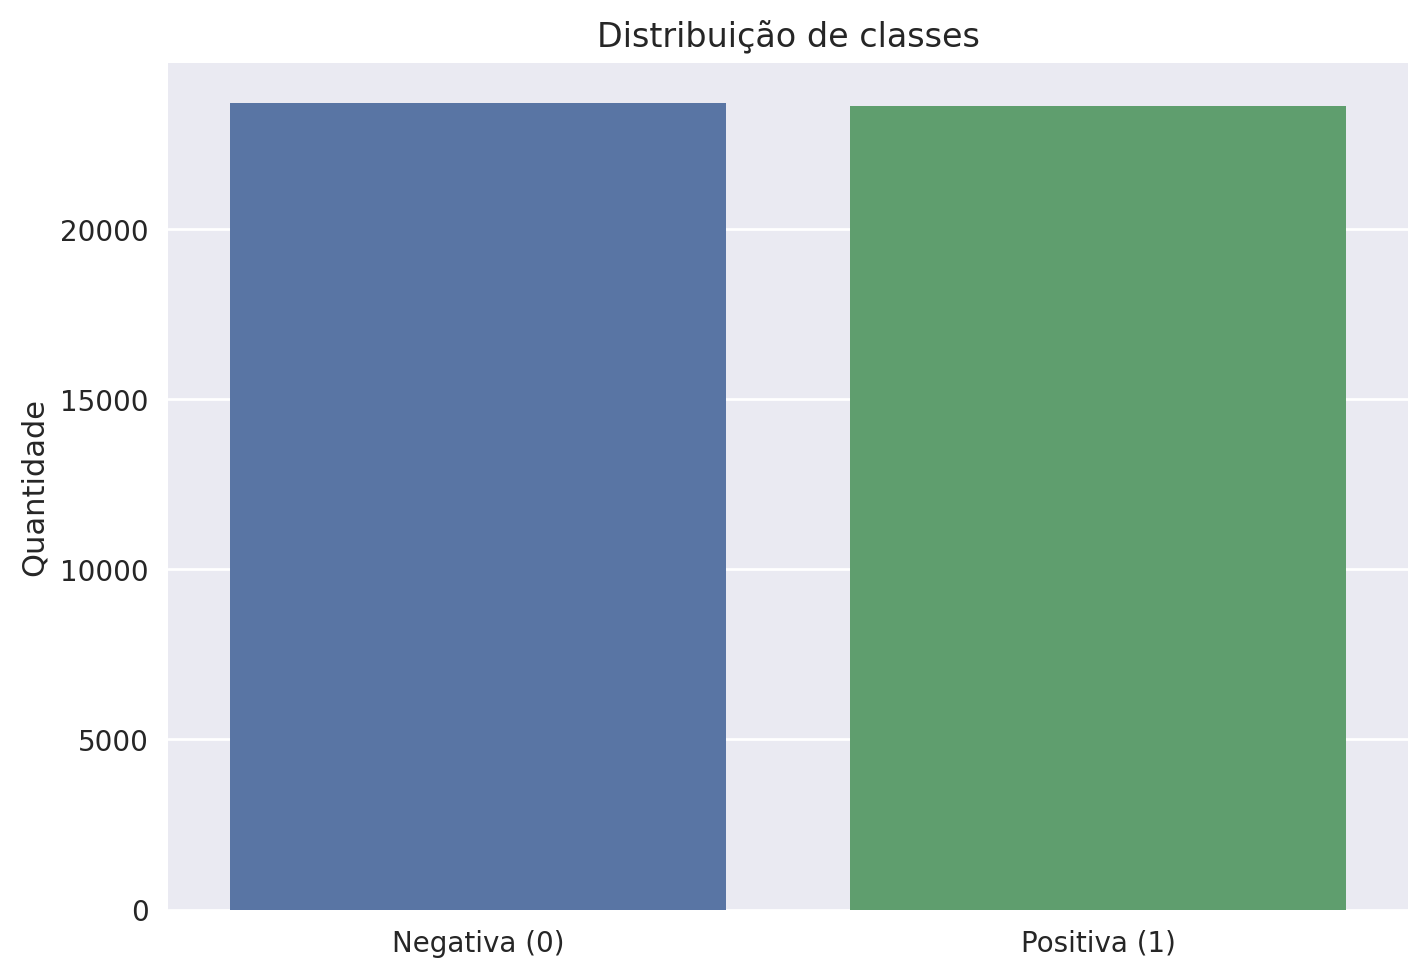

In [ ]:
class_counts = df_reviews['pos'].value_counts().sort_index()
class_perc = df_reviews['pos'].value_counts(normalize=True).sort_index() * 100

display(class_counts)
display(class_perc)

sns.barplot(x=class_counts.index, y=class_counts.values)
plt.xticks([0, 1], ['Negativa (0)', 'Positiva (1)'])
plt.title('Distribuição de classes')
plt.ylabel('Quantidade')
plt.show()


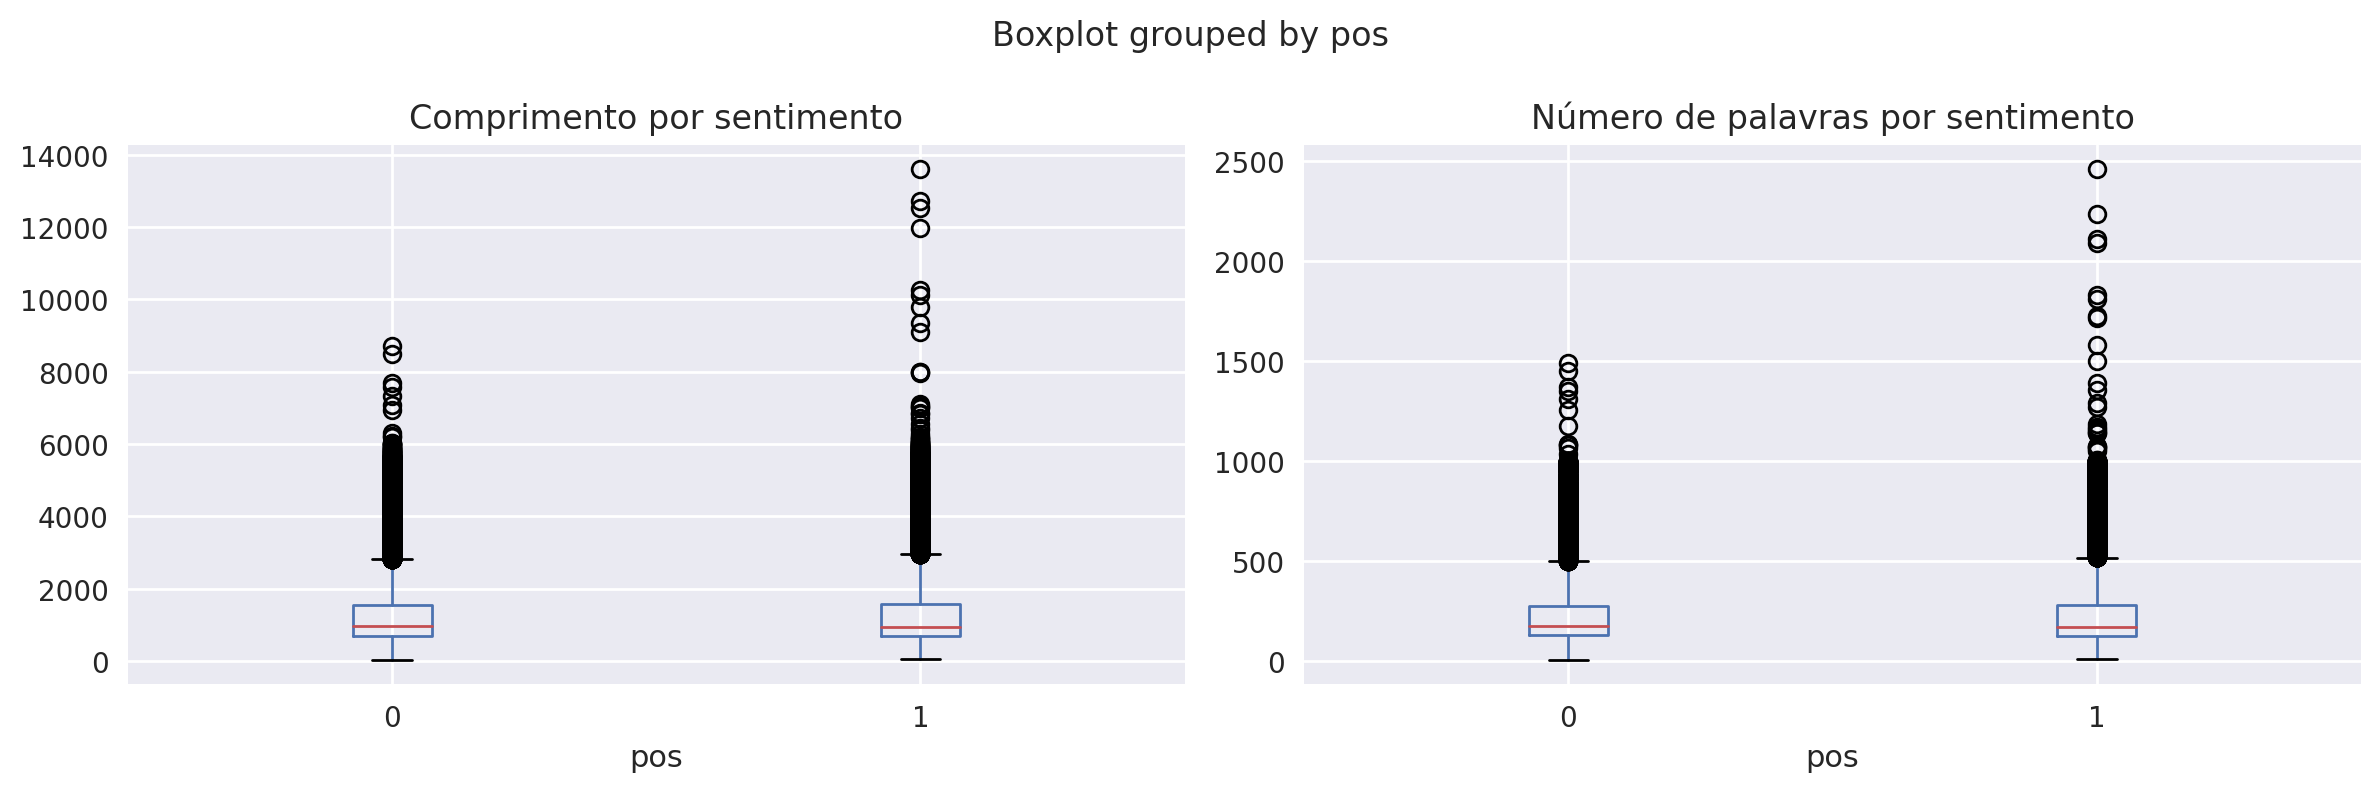

In [ ]:
# Análise do comprimento dos textos
df_reviews['review_length'] = df_reviews['review'].str.len()
df_reviews['review_words'] = df_reviews['review'].str.split().str.len()

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
df_reviews.boxplot(column='review_length', by='pos', ax=plt.gca())
plt.title('Comprimento por sentimento')

plt.subplot(1, 2, 2)
df_reviews.boxplot(column='review_words', by='pos', ax=plt.gca())
plt.title('Número de palavras por sentimento')
plt.tight_layout()


## Procedimento de Avaliação

Compondo uma rotina de avaliação que pode ser utilizada para todos os modelos deste projeto

In [ ]:
import sklearn.metrics as metrics

def evaluate_model(model, train_features, train_target, test_features, test_target):
    
    eval_stats = {}
    
    fig, axs = plt.subplots(1, 3, figsize=(20, 6)) 
    
    for type, features, target in (('train', train_features, train_target), ('test', test_features, test_target)):
        
        eval_stats[type] = {}
    
        pred_target = model.predict(features)
        pred_proba = model.predict_proba(features)[:, 1]
        
        # F1
        f1_thresholds = np.arange(0, 1.01, 0.05)
        f1_scores = [metrics.f1_score(target, pred_proba>=threshold) for threshold in f1_thresholds]
        
        # ROC
        fpr, tpr, roc_thresholds = metrics.roc_curve(target, pred_proba)
        roc_auc = metrics.roc_auc_score(target, pred_proba)    
        eval_stats[type]['ROC AUC'] = roc_auc

        # Curva de precisão-revocação
        precision, recall, pr_thresholds = metrics.precision_recall_curve(target, pred_proba)
        aps = metrics.average_precision_score(target, pred_proba)
        eval_stats[type]['APS'] = aps
        
        if type == 'train':
            color = 'blue'
        else:
            color = 'green'

        # Valor F1
        ax = axs[0]
        max_f1_score_idx = np.argmax(f1_scores)
        ax.plot(f1_thresholds, f1_scores, color=color, label=f'{type}, max={f1_scores[max_f1_score_idx]:.2f} @ {f1_thresholds[max_f1_score_idx]:.2f}')
        # definindo cruzamentos para alguns limiares
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(f1_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(f1_thresholds[closest_value_idx], f1_scores[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('threshold')
        ax.set_ylabel('F1')
        ax.legend(loc='lower center')
        ax.set_title(f'Valor F1') 

        # ROC
        ax = axs[1]    
        ax.plot(fpr, tpr, color=color, label=f'{type}, ROC AUC={roc_auc:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(roc_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'            
            ax.plot(fpr[closest_value_idx], tpr[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.plot([0, 1], [0, 1], color='grey', linestyle='--')
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('FPR')
        ax.set_ylabel('TPR')
        ax.legend(loc='lower center')        
        ax.set_title(f'Curva ROC')
        
        # Curva de precisão-revocação
        ax = axs[2]
        ax.plot(recall, precision, color=color, label=f'{type}, AP={aps:.2f}')
        # definindo cruzamentos para alguns limiares
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(pr_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(recall[closest_value_idx], precision[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('recall')
        ax.set_ylabel('precision')
        ax.legend(loc='lower center')
        ax.set_title(f'PRC')        

        eval_stats[type]['Accuracy'] = metrics.accuracy_score(target, pred_target)
    
    # Calcular F1 score para o threshold padrão (0.5)
    eval_stats[type]['F1'] = metrics.f1_score(target, pred_proba >= 0.5)
    
    df_eval_stats = pd.DataFrame(eval_stats)
    df_eval_stats = df_eval_stats.round(2)
    df_eval_stats = df_eval_stats.reindex(index=('Accuracy', 'F1', 'APS', 'ROC AUC'))
    
    print(df_eval_stats)
    
    return


## Normalização

Assumimos que todos os modelos abaixo aceitam textos em letras minúsculas e sem dígitos, sinais de pontuação, etc.

In [ ]:
import re

def normalize_text(text):
    text = str(text).lower()
    # remove tags HTML
    text = re.sub(r'<.*?>', ' ', text)
    # deixa só letras (a–z)
    text = re.sub(r'[^a-z]+', ' ', text)
    # remove espaços extras
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_reviews['review_norm'] = df_reviews['review'].apply(normalize_text)


## Treinar / Testar Conjunto

Felizmente, todo o conjunto de dados já está dividido em partes de treinamento/teste. A opção correspondente é 'ds_part'.

In [ ]:
df_reviews_train = df_reviews.query('ds_part == "train"').copy()
df_reviews_test = df_reviews.query('ds_part == "test"').copy()

train_target = df_reviews_train['pos']
test_target = df_reviews_test['pos']

print(df_reviews_train.shape)
print(df_reviews_test.shape)


(23796, 20)
(23535, 20)


In [18]:
# Features básicas para o modelo baseline
train_features = df_reviews_train['review_norm']  
test_features = df_reviews_test['review_norm']  


In [ ]:
train_features_dummy = np.zeros((len(train_target), 1))
test_features_dummy = np.zeros((len(test_target), 1))


## Trabalhando com modelos

### Modelo 0 - Constante

In [ ]:
from sklearn.dummy import DummyClassifier


In [ ]:
model_0 = DummyClassifier(strategy="most_frequent")
model_0.fit(train_features_dummy, train_target)


DummyClassifier(strategy='most_frequent')

          train  test
Accuracy    0.5   0.5
F1          NaN   0.0
APS         0.5   0.5
ROC AUC     0.5   0.5


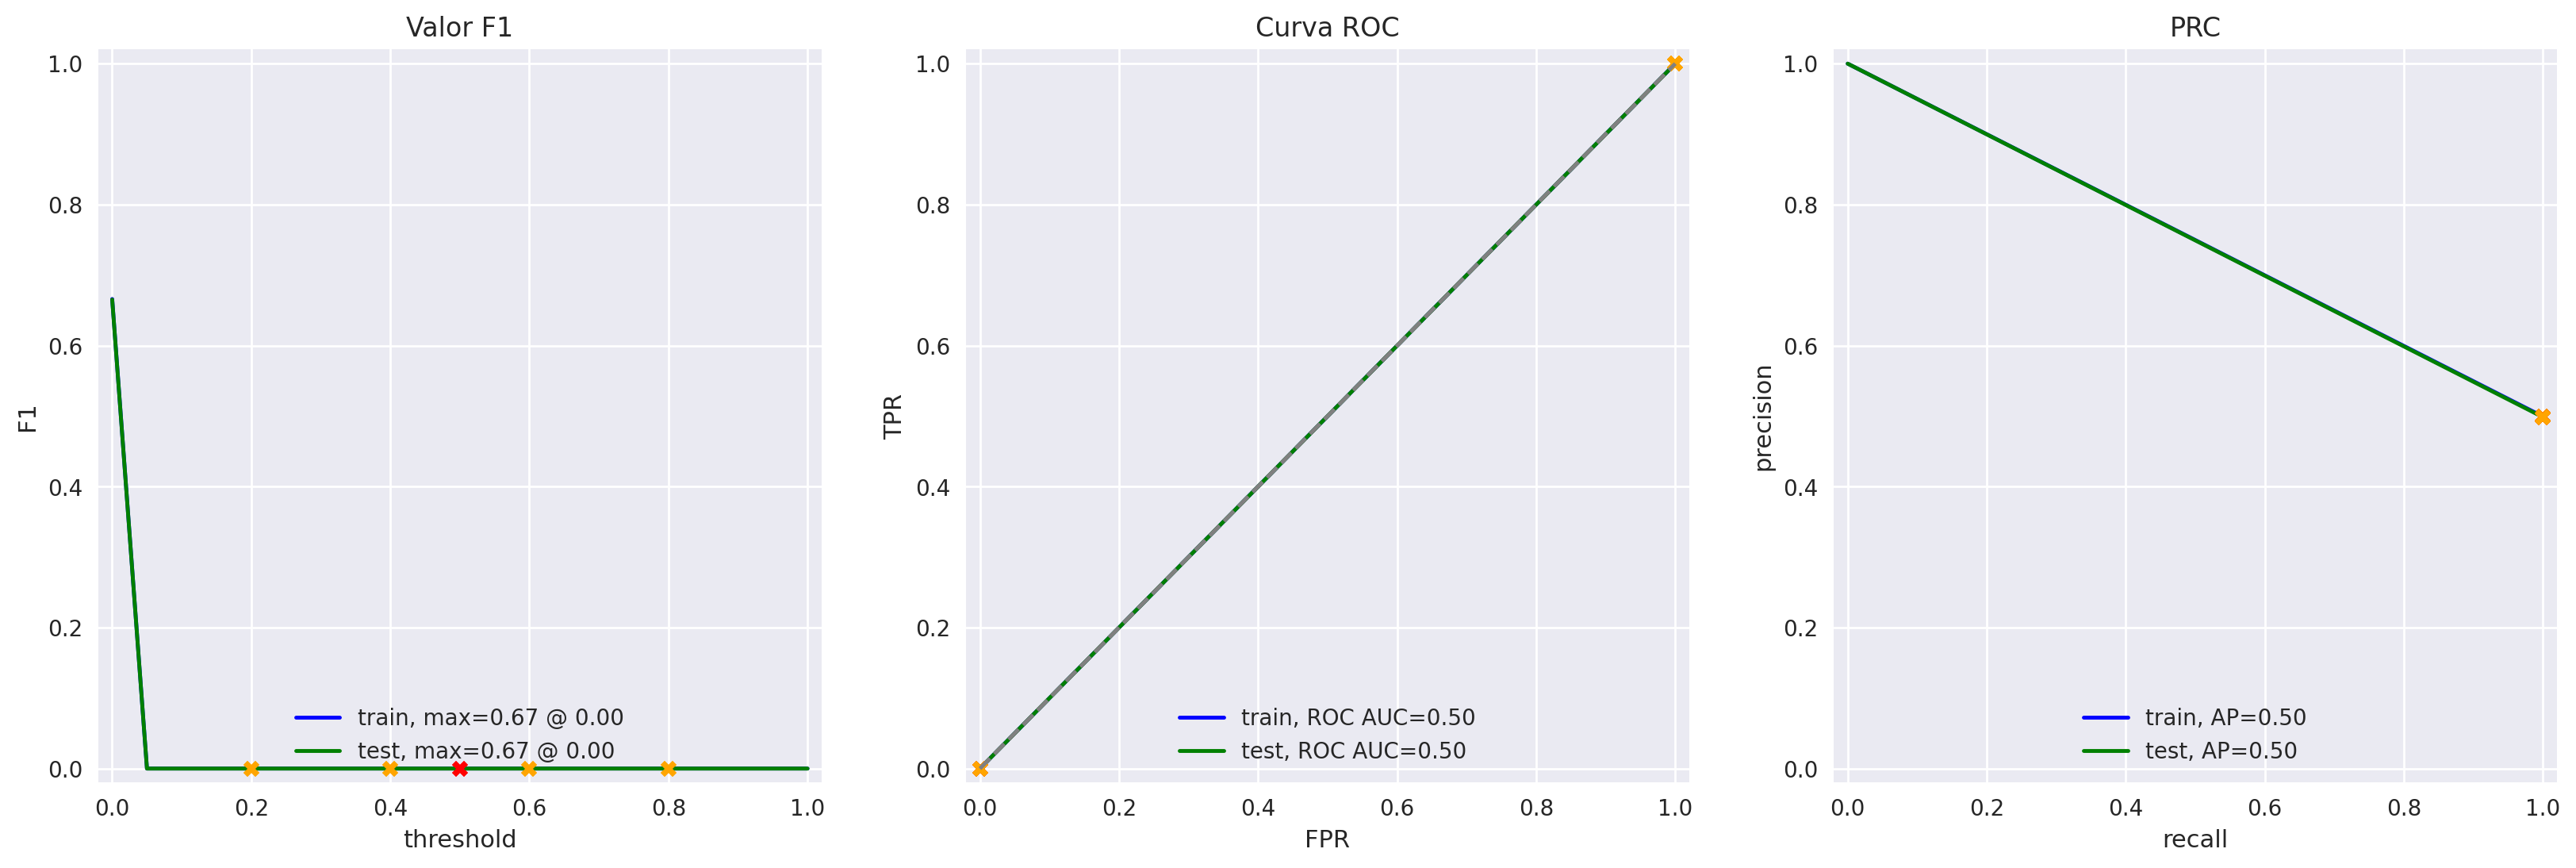

In [ ]:
evaluate_model(model_0, train_features_dummy, train_target, test_features_dummy, test_target)


### Modelo 1 - NLTK, TF-IDF e Regressão Linear

TF-IDF

In [ ]:
import nltk

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from nltk.corpus import stopwords


In [24]:
# baixar stopwords
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

# Remover palavras de negação das stopwords
negation_words = {'not', 'no', 'nor', 'don', 'don\'t', 'aren', 'aren\'t', 
                  'couldn', 'couldn\'t', 'didn', 'didn\'t', 'doesn', 'doesn\'t',
                  'hadn', 'hadn\'t', 'hasn', 'hasn\'t', 'haven', 'haven\'t',
                  'isn', 'isn\'t', 'mightn', 'mightn\'t', 'mustn', 'mustn\'t',
                  'needn', 'needn\'t', 'shan', 'shan\'t', 'shouldn', 'shouldn\'t',
                  'wasn', 'wasn\'t', 'weren', 'weren\'t', 'won', 'won\'t',
                  'wouldn', 'wouldn\'t', 'never', 'nothing', 'nowhere', 'nobody'}

# Remover palavras de negação das stopwords
stop_words = stop_words - negation_words

# vetorizar os textos normalizados
tfidf_vectorizer_1 = TfidfVectorizer(
    lowercase=False,          # já colocamos tudo em minúsculo em normalize_text
    stop_words=stop_words,
    ngram_range=(1, 2),
    min_df=5
)

train_features_1 = tfidf_vectorizer_1.fit_transform(df_reviews_train['review_norm'])
test_features_1 = tfidf_vectorizer_1.transform(df_reviews_test['review_norm'])


[nltk_data] Downloading package stopwords to
[nltk_data]     /home/student/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


<s>
<div class="alert alert-block alert-warning">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

- cuidado que not, don't faz parte de stopwords e sua remoção pode alterar a frase: I don't like this movie -> I like this movie
</div>

In [ ]:
model_1 = LogisticRegression(max_iter=1000, n_jobs=-1, random_state=42)
model_1.fit(train_features_1, train_target)


LogisticRegression(max_iter=1000, n_jobs=-1, random_state=42)

          train  test
Accuracy   0.95  0.89
F1          NaN  0.89
APS        0.99  0.95
ROC AUC    0.99  0.96


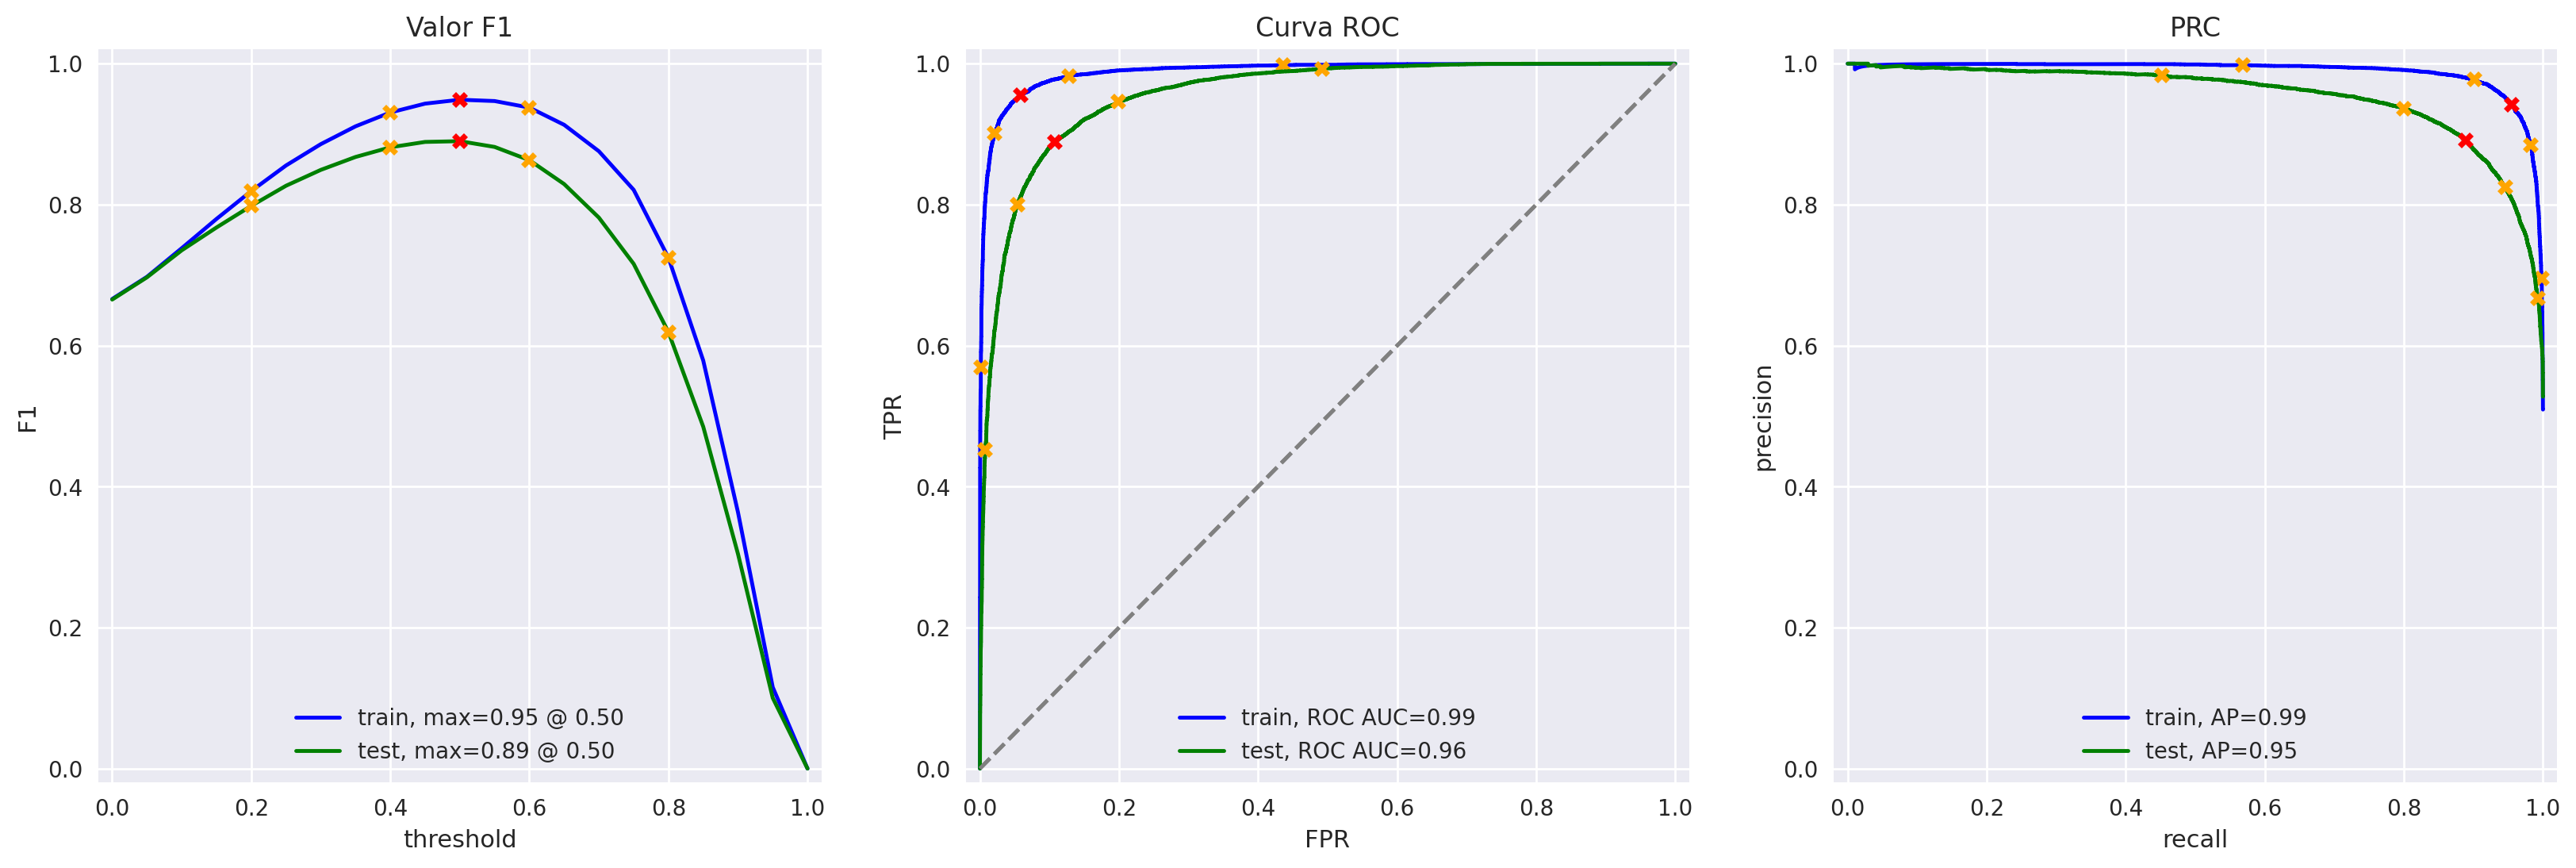

In [ ]:
evaluate_model(model_1, train_features_1, train_target, test_features_1, test_target)


### Modelo 3 - spaCy, TF-IDF e Regressão Linear

In [ ]:
import spacy

nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])


In [ ]:
def text_preprocessing_3(text):
    
    doc = nlp(text)
    #tokens = [token.lemma_ for token in doc if not token.is_stop]
    tokens = [token.lemma_ for token in doc]
    
    return ' '.join(tokens)


In [29]:
tfidf_vectorizer_3 = TfidfVectorizer(
    lowercase=False,
    ngram_range=(1, 2),
    min_df=5
)

train_texts_3 = df_reviews_train['review_norm'].apply(text_preprocessing_3)
test_texts_3 = df_reviews_test['review_norm'].apply(text_preprocessing_3)

train_features_3 = tfidf_vectorizer_3.fit_transform(train_texts_3)
test_features_3 = tfidf_vectorizer_3.transform(test_texts_3)


In [30]:
model_3 = LogisticRegression(max_iter=1000, n_jobs=-1, random_state=42)
model_3.fit(train_features_3, train_target)


LogisticRegression(max_iter=1000, n_jobs=-1, random_state=42)

          train  test
Accuracy   0.95  0.89
F1          NaN  0.89
APS        0.99  0.96
ROC AUC    0.99  0.96


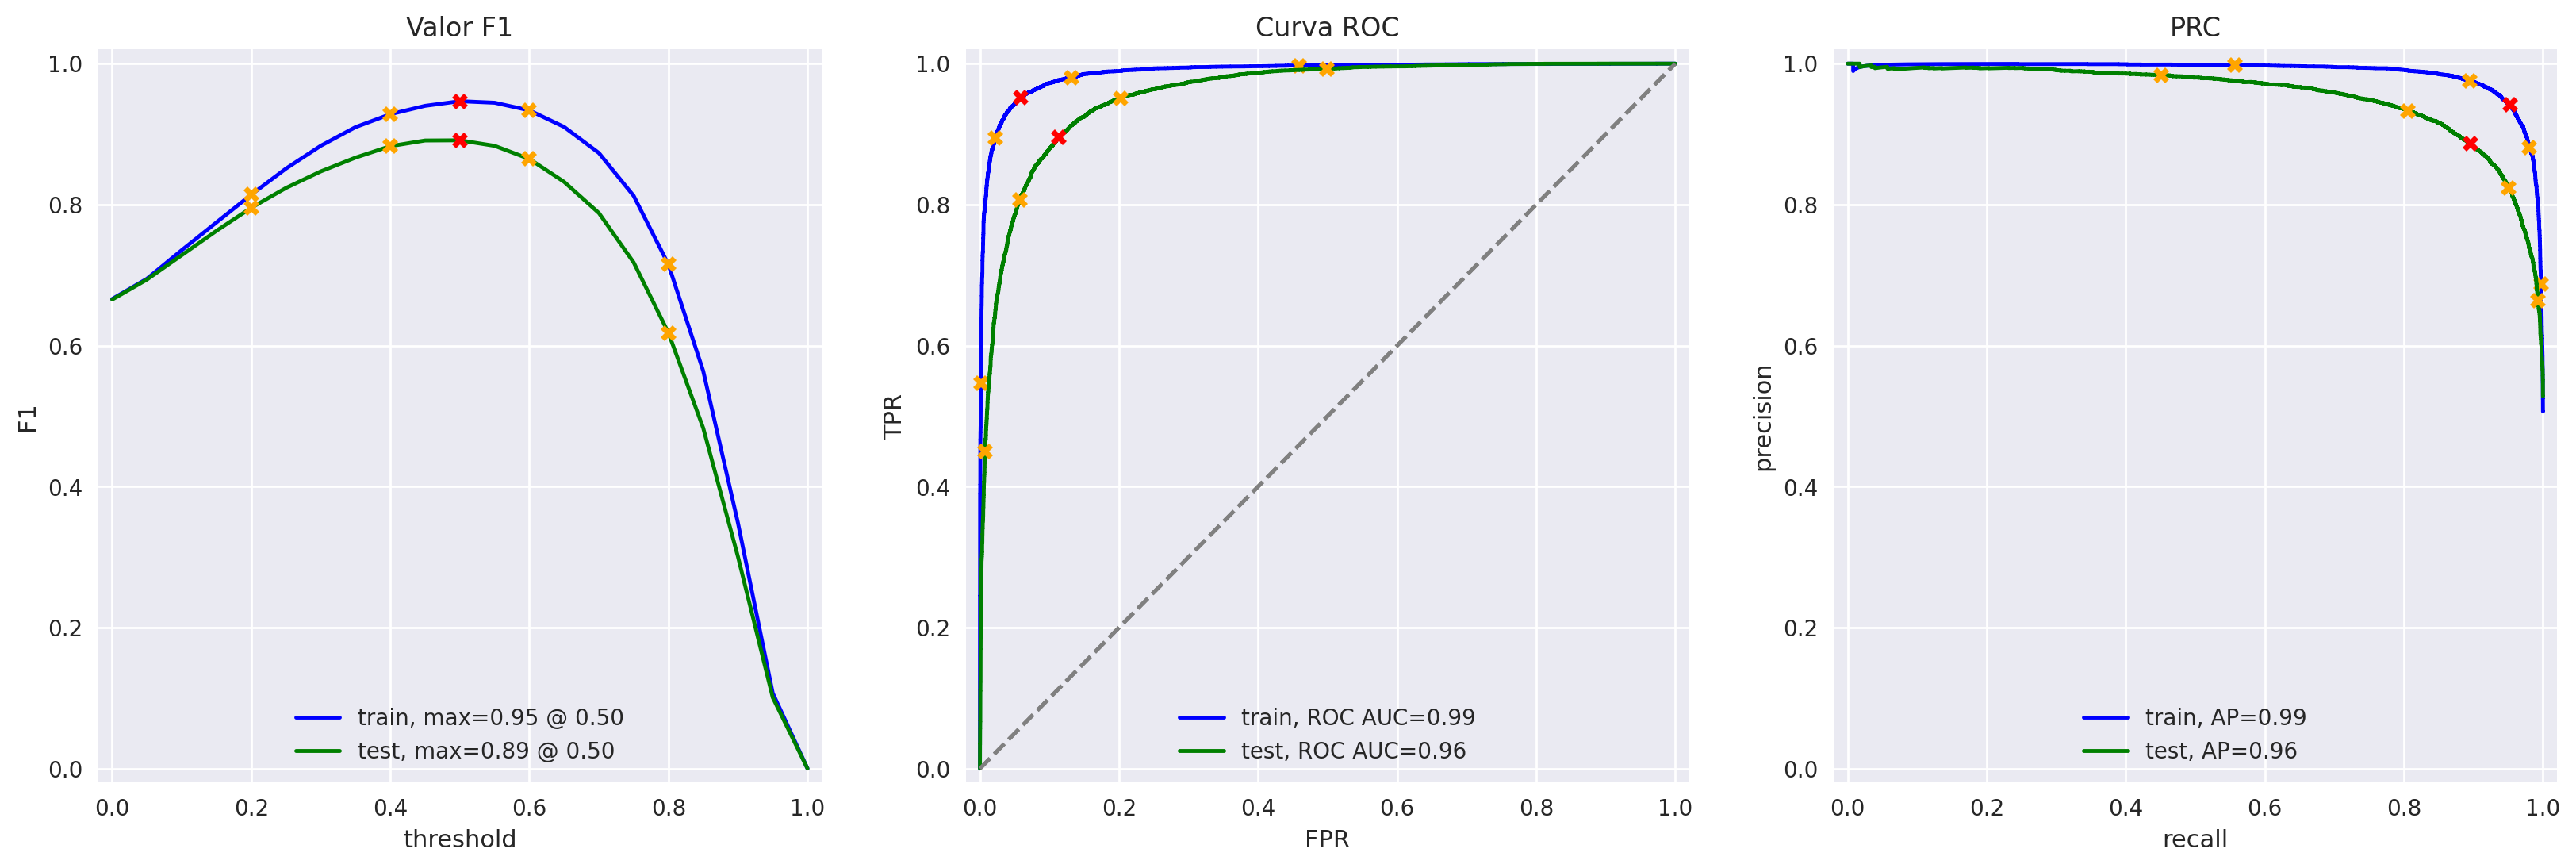

In [31]:
evaluate_model(model_3, train_features_3, train_target, test_features_3, test_target)


### Modelo 4 - SpaCy, TF-IDF e LGBMClassifier

In [ ]:
from lightgbm import LGBMClassifier


In [ ]:
# vamos reaproveitar as mesmas features do Modelo 3
tfidf_vectorizer_4 = tfidf_vectorizer_3
train_features_4 = train_features_3
test_features_4 = test_features_3


In [ ]:
model_4 = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.1,
    num_leaves=31,
    random_state=42
)

model_4.fit(train_features_4, train_target)


LGBMClassifier(n_estimators=200, random_state=42)

          train  test
Accuracy   0.97  0.88
F1          NaN  0.88
APS        1.00  0.95
ROC AUC    1.00  0.95


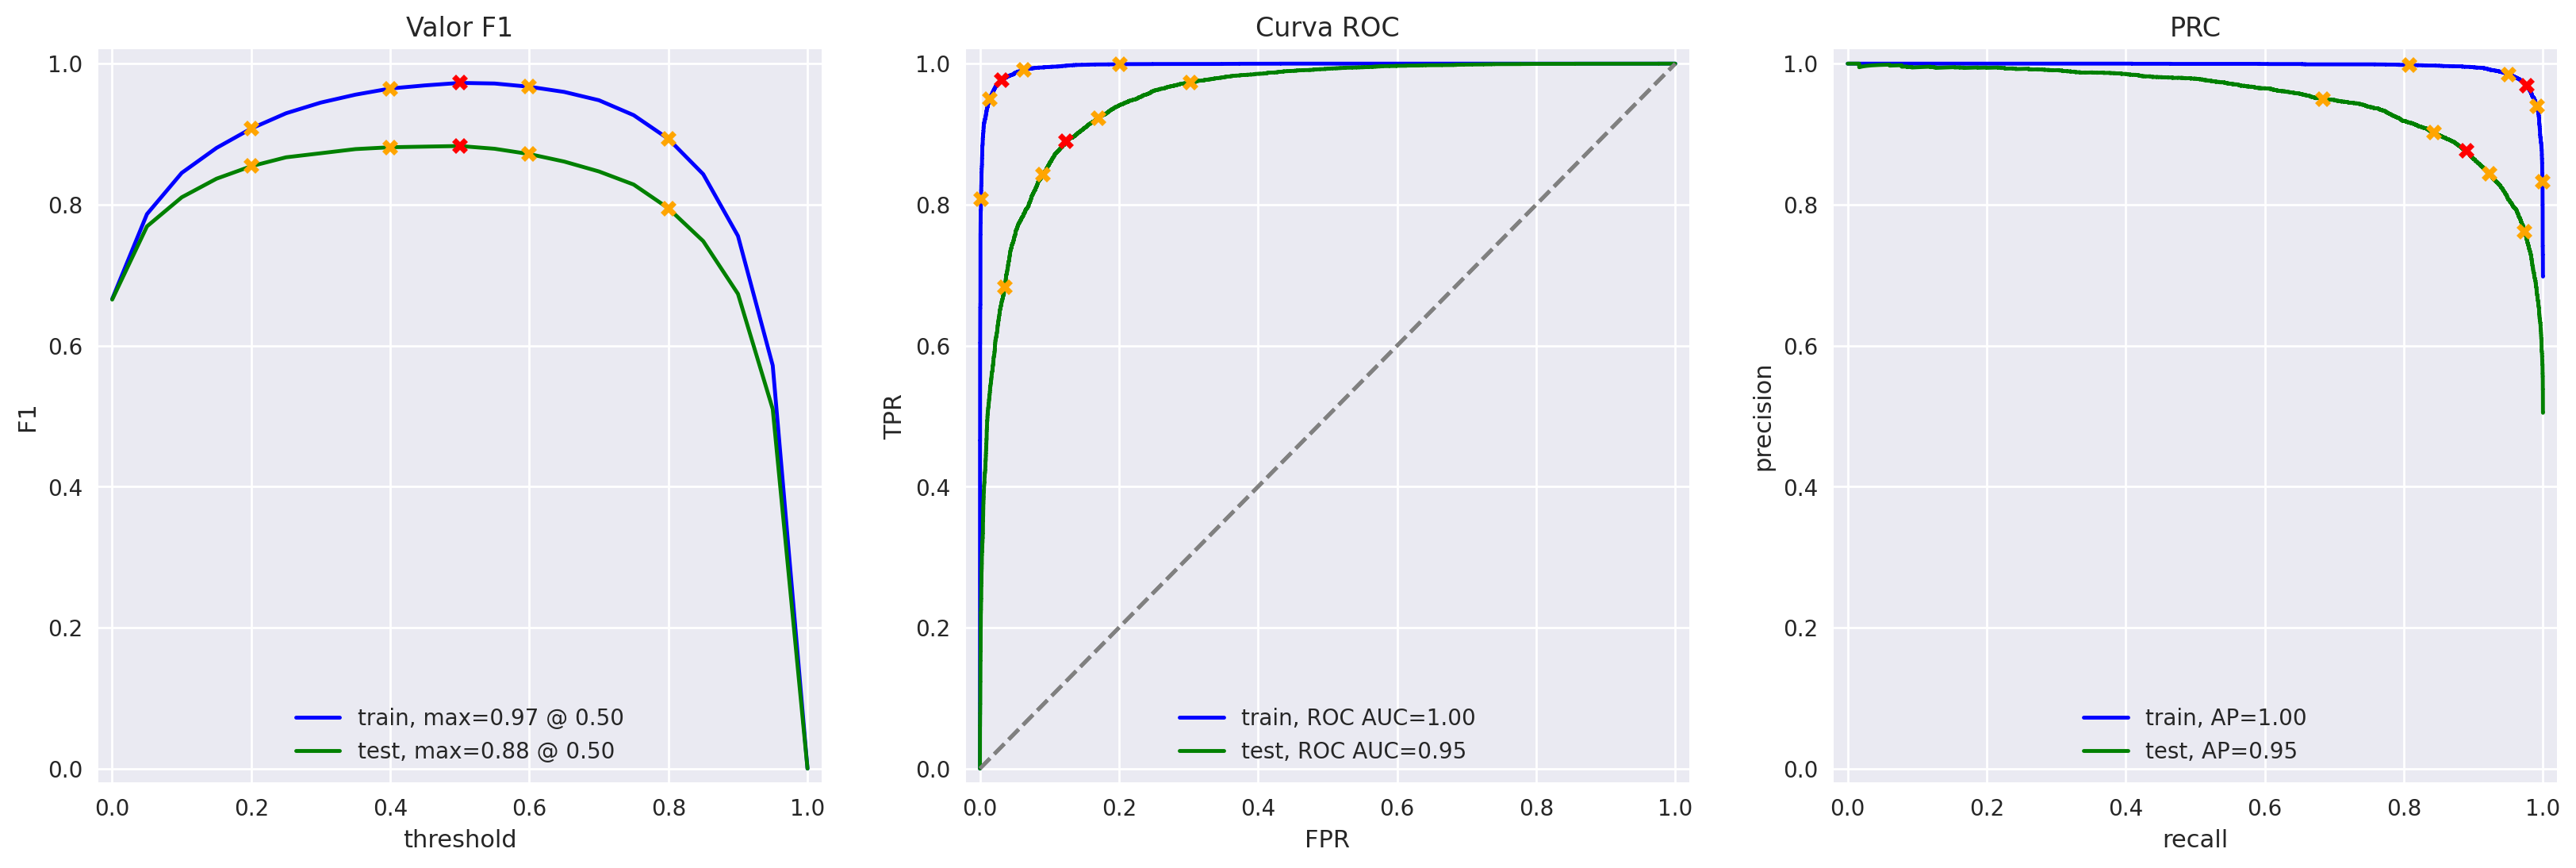

In [ ]:
evaluate_model(model_4, train_features_4, train_target, test_features_4, test_target)


###  Modelo 9 - BERT

In [ ]:
import torch
import transformers


In [ ]:
tokenizer = transformers.BertTokenizer.from_pretrained('bert-base-uncased')
config = transformers.BertConfig.from_pretrained('bert-base-uncased')
model = transformers.BertModel.from_pretrained('bert-base-uncased')


Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertModel: ['cls.predictions.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.bias', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.decoder.weight', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [38]:
def BERT_text_to_embeddings(texts, max_length=512, batch_size=100, force_device=None, disable_progress_bar=False):
    
    ids_list = []
    attention_mask_list = []

    # texto -> IDs de tokens + máscaras de atenção
    for text in texts:
        encoded = tokenizer.encode_plus(
            str(text),
            add_special_tokens=True,
            max_length=max_length,
            truncation=True,
            padding='max_length',
            return_attention_mask=True
        )
        ids_list.append(encoded['input_ids'])
        attention_mask_list.append(encoded['attention_mask'])
    
    if force_device is not None:
        device = torch.device(force_device)
    else:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
    model.to(device)
    if not disable_progress_bar:
        print(f'Usando o dispositivo {device}.')
        
    # recebendo incorporações em lotes
    embeddings = []

    for i in tqdm(range(math.ceil(len(ids_list)/batch_size)), disable=disable_progress_bar):
            
        ids_batch = torch.LongTensor(ids_list[batch_size*i:batch_size*(i+1)]).to(device)
        attention_mask_batch = torch.LongTensor(attention_mask_list[batch_size*i:batch_size*(i+1)]).to(device)
            
        with torch.no_grad():            
            model.eval()
            batch_embeddings = model(input_ids=ids_batch, attention_mask=attention_mask_batch)   
        embeddings.append(batch_embeddings[0][:, 0, :].detach().cpu().numpy())
        
    return np.concatenate(embeddings)


In [ ]:
# Atenção! A execução do BERT para milhares de textos pode levar muito tempo na CPU, pelo menos várias horas
train_features_9 = BERT_text_to_embeddings(df_reviews_train['review_norm'], force_device='cuda')


RuntimeError: Found no NVIDIA driver on your system. Please check that you have an NVIDIA GPU and installed a driver from http://www.nvidia.com/Download/index.aspx

In [ ]:
print(df_reviews_train['review_norm'].shape)
print(train_features_9.shape)
print(train_target.shape)


In [ ]:
# Gerar embeddings para o conjunto de teste
test_features_9 = BERT_text_to_embeddings(
    df_reviews_test['review_norm'], 
    force_device='cuda'  # ou 'cpu' se não tiver GPU
)


In [ ]:
from sklearn.linear_model import LogisticRegression

# Criar e treinar o modelo
model_9 = LogisticRegression(random_state=12345, max_iter=1000)
model_9.fit(train_features_9, train_target)


In [ ]:
evaluate_model(model_9, train_features_9, train_target, test_features_9, test_target)


In [ ]:
# se você tiver as incorporações, é aconselhável salvá-las para tê-las prontas se 
# np.savez_compressed('features_9.npz', train_features_9=train_features_9, test_features_9=test_features_9)

# e carregar...
# with np.load('features_9.npz') as data:
#     train_features_9 = data['train_features_9']
#     test_features_9 = data['test_features_9']


## Minhas Resenhas

In [ ]:
# sinta-se à vontade para remover completamente essas resenhas e experimentar seus modelos nas suas próprias resenhas, as abaixo são apenas exemplos

my_reviews = pd.DataFrame([
    'I simply didn\'t like it, it\'s not my type of movie.',
    'Well, I got bored and fell asleep in the middle of the movie.',
    'I was really fascinated by the movie',
    'The actors seemed very old and uninterested, and yet they were paid to participate in the movie. What a shameless money grab.',
    'I didn\'t expect the new version to be so good! The writers really cared about the original material',
    'The movie has its pros and cons, but I feel that overall it\'s a decent movie. I can imagine myself going to watch it again.',
    'What a rotten attempt at comedy. Not a single joke lands, everyone acts annoying and loud, not even kids will like this!',
    'Releasing on Netflix was a bold move and I really appreciate being able to watch episode after episode of this exciting and intelligent new drama.'
], columns=['review'])

my_reviews['review_norm'] = my_reviews['review'].apply(normalize_text)
my_reviews


,review,review_norm
0,"I simply didn't like it, it's not my type of m...",i simply didn t like it it s not my type of movie
1,"Well, I got bored and fell asleep in the middl...",well i got bored and fell asleep in the middle...
2,I was really fascinated by the movie,i was really fascinated by the movie
3,"The actors seemed very old and uninterested, a...",the actors seemed very old and uninterested an...
4,I didn't expect the new version to be so good!...,i didn t expect the new version to be so good ...
5,"The movie has its pros and cons, but I feel th...",the movie has its pros and cons but i feel tha...
6,What a rotten attempt at comedy. Not a single ...,what a rotten attempt at comedy not a single j...
7,Releasing on Netflix was a bold move and I rea...,releasing on netflix was a bold move and i rea...


### Modelo 2

In [ ]:
#texts = my_reviews['review_norm']

#my_reviews_pred_prob = model_2.predict_proba(tfidf_vectorizer_2.transform(texts))[:, 1]

#for i, review in enumerate(texts.str.slice(0, 100)):
    #print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')


### Modelo 3

In [ ]:
texts = my_reviews['review_norm']

my_reviews_pred_prob = model_3.predict_proba(
    tfidf_vectorizer_3.transform(texts.apply(lambda x: text_preprocessing_3(x)))
)[:, 1]



for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')


0.49:  i simply didn t like it it s not my type of movie
0.27:  well i got bored and fell asleep in the middle of the movie
0.49:  i was really fascinated by the movie
0.26:  the actors seemed very old and uninterested and yet they were paid to participate in the movie what 
0.21:  i didn t expect the new version to be so good the writers really cared about the original material
0.58:  the movie has its pros and cons but i feel that overall it s a decent movie i can imagine myself goi
0.11:  what a rotten attempt at comedy not a single joke lands everyone acts annoying and loud not even kid
0.84:  releasing on netflix was a bold move and i really appreciate being able to watch episode after episo


### Modelo 4

In [ ]:
texts = my_reviews['review_norm']

tfidf_vectorizer_4 = tfidf_vectorizer_3
my_reviews_pred_prob = model_4.predict_proba(
    tfidf_vectorizer_4.transform(texts.apply(lambda x: text_preprocessing_3(x)))
)[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')


0.66:  i simply didn t like it it s not my type of movie
0.31:  well i got bored and fell asleep in the middle of the movie
0.62:  i was really fascinated by the movie
0.66:  the actors seemed very old and uninterested and yet they were paid to participate in the movie what 
0.33:  i didn t expect the new version to be so good the writers really cared about the original material
0.79:  the movie has its pros and cons but i feel that overall it s a decent movie i can imagine myself goi
0.18:  what a rotten attempt at comedy not a single joke lands everyone acts annoying and loud not even kid
0.87:  releasing on netflix was a bold move and i really appreciate being able to watch episode after episo


### Modelo 9

In [ ]:
texts = my_reviews['review_norm']

my_reviews_features_9 = BERT_text_to_embeddings(texts, disable_progress_bar=True)

my_reviews_pred_prob = model_9.predict_proba(my_reviews_features_9)[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')


NameError: name 'model_9' is not defined

## Conclusões

In [ ]:
# Conclusões do projeto:

# RESULTADOS DOS MODELOS:
# - O Modelo 0 (baseline) teve F1 = 0.0, servindo como referência mínima
# - O Modelo 1 (NLTK + TF-IDF + Regressão Logística) atingiu F1 de 0.89 no conjunto de teste
# - O Modelo 3 (spaCy + TF-IDF + Regressão Logística) teve F1 de 0.89, igual ao Modelo 1
# - O Modelo 4 (spaCy + TF-IDF + LGBM) teve F1 de 0.88, ligeiramente inferior aos anteriores
# - O Modelo 9 (BERT) não foi completado devido à ausência de GPU no ambiente atual

# ANÁLISE COMPARATIVA:
# - Todos os modelos implementados superaram o requisito mínimo de F1 ≥ 0.85
# - Os Modelos 1 e 3 tiveram desempenho idêntico (F1 = 0.89)
# - A diferença entre NLTK e spaCy para pré-processamento foi mínima neste dataset
# - O LGBM teve desempenho ligeiramente inferior à Regressão Logística

# RECOMENDAÇÕES:
# - O Modelo 1 é recomendado por sua simplicidade e excelente desempenho
# - Todos os modelos são adequados para produção, atendendo ao critério de qualidade
# - Para implementação, o Modelo 1 seria mais eficiente computacionalmente
